# Univariate Analysis

- **Bar plots** for visualizing **binary variables**.  
- **Histograms** for **ordinal and nominal variables**.  
- **Histograms** for **continuous and discrete numeric variables**.  


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read Dataset
the dataset has been previously cleaned and encoded
- typo correction and missing values and text standardized
- outlier detection and treatment on numeric variables
- variable encoding on binary/nominal/ordinal variables

In [2]:
data = pd.read_csv("../data/interim/04. FRAIL_var_encoded.csv")
print(data.shape)
data.head()

(6841, 86)


,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,...,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100,HANDGRIP_DIREITA_tentativa_2
0,19,1,1,2021-11-16,1941-08-20,80.0,0,1.0,2.0,153.0,...,1.0,0.0,16.0,1.0,1.0,1.0,1.0,2.0,80.0,12.0
1,19,3,1,2022-11-16,1941-08-20,81.0,0,1.0,2.0,152.0,...,1.0,0.0,20.0,2.0,2.0,2.0,2.0,1.0,80.0,12.9
2,19,4,1,2023-06-20,1941-08-20,81.0,0,1.0,2.0,153.0,...,1.0,0.0,16.0,1.0,1.0,1.0,2.0,1.0,90.0,7.0
3,37,1,1,2021-11-16,1948-11-20,72.0,0,1.0,2.0,149.0,...,1.0,0.0,20.0,1.0,1.0,1.0,1.0,2.0,100.0,22.9
4,37,2,1,2022-06-29,1948-11-20,73.0,0,1.0,2.0,150.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,15.7


## Define column types

In [3]:
numerical_columns = ["Age", 'ANTROPOMETRIA_Estatura_cm', 'ANTROPOMETRIA_Peso_Kg', 'Quedas_12meses_Hospitalizado_Dias', 
                     'ATIVIDADE_FISICA_Caminhada_Duracao_min_dia', 'ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia',
                     'ANTROPOMETRIA_Massa_gorda', 'ANTROPOMETRIA_Massa_magra_Kg', 'ANTROPOMETRIA_Gordura_visceral',
                     'HANDGRIP_DIREITA_tentaiva1', 'HANDGRIP_DIREITA_tentativa2', 'HANDGRIP_DIREITA_tentativa_3',
                     'HANDGRIP_ESQUERDA_tentativa1', 'HANDGRIP_ESQUERDA_tentativa2', 'HANDGRIP_ESQUERDA_tentativa3',
                     'TIMED_UP_AND_GO_Simples_tentativa1', 'TIMED_UP_AND_GO_Simples_tentativa2', 'Best_TIMED_UP_AND_GO_Simples',
                     'TIMED_UP_AND_GO_Dupla_tarefa_tentativa1', 'TIMED_UP_AND_GO_Dupla_tarefa_tentativa2', 'Best_TIMED_UP_AND_GO_Dupla_tarefa', 'SIT_TO_STAND_Repetiçoes', 
                     '@6_MIN_ANDAR_N_voltas_completas', '@6_MIN_ANDAR_Resultado_teste_Metros', '@6_MIN_ANDAR_Distancia_TOTAL_metros',
                     'MMSE_Total', 'EQ5D5L_A_sua_saude_hoje_0_100']

discrete_columns = ['EQ5D5L_MOBILIDADE', 'EQ5D5L_CUIDADOS_PESSOAIS', 'EQ5D5L_ATIVIDADES_HABITUAIS', 'EQ5D5L_DOR_MAL_ESTAR', 'EQ5D5L_ANSIEDADE_DEPRESSAO',
                    'MMSE_LINGUAGEM_B_REPETICAO', 'MMSE_LINGUAGEM_C_COMANDO', 'MMSE_LINGUAGEM_D_LEITURA', 'MMSE_LINGUAGEM_E_FRASE_ESCRITA', 'MMSE_COPIA_DESENHO_1',
                    'MMSE_ORIENTACAO_TEMPORAL', 'MMSE_ORIENTACAO_ESPACIAL', 'MMSE_RETENCAO', 'MMSE_ATENCAO_CALCULO', 'MMSE_EVOCACAO_1', 'MMSE_LINGUAGEM_A_NOMEACAO',
                    "Freq_semanal", 'Quedas_12meses_Quantas','ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana', 'ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana',
                    '@6_MIN_ANDAR_Parou_Quantas_vezes']

binary_columns = ['Genero', 'Quedas_ultimos_12meses', 'Quedas_12meses_Lesao_Sim_Nao', 'Quedas_12meses_Assistencia_hospitalar_Sim_Não', 'Quedas_12meses_Hospitalizado_Sim_Não', 'Quedas_12meses_Medo_cair_Sim_Não',
                  'ATIVIDADE_FISICA_Geral_Sim_Não', 'HANDGRIP_Mao_DOMINANTE', 'TIMED_UP_AND_GO_Simples_Apoio_mãos', 'TIMED_UP_AND_GO_Simples_Auxiliar_marcha', 'TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos',
                  'TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha', 'SIT_TO_STAND_Apoio_maos', 'SIT_TO_STAND_Auxiliar_marcha', '@6_MIN_ANDAR_Auxiliar_marcha', '@6_MIN_ANDAR_Parou']


ordinal_columns = ['Escolaridade', 'ATIVIDADE_FISICA_Caminhada_Intensidade', 'ATIVIDADE_FISICA_Outras_AF_Intensidade', 'Percentil_TIMED_UP_AND_GO_Simples',
                   'Percentil_TIMED_UP_AND_GO_Dupla_tarefa', 'Percentil_SIT_TO_STAND_Repetiçoes', 'Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros', 'MMSE_EDUCAÇAO']


nominal_columns = ['Momento', 'Local_de_Avaliacao', 'Modalidade', '@6_MIN_ANDAR_Percurso']

columns_embedding = ["Quedas_12meses_Situacao", "Quedas_12meses_Lesao_Tipo", "Quedas_12meses_Lesao_Local", "@6_MIN_ANDAR_Parou_Motivo", "ATIVIDADE_FISICA_Outras_AF_Qual", "@6_MIN_ANDAR_Desistiu"]

other_columns = data.columns.drop(numerical_columns).drop(binary_columns).drop(ordinal_columns).drop(nominal_columns).drop(columns_embedding).drop(discrete_columns)
other_columns

Index(['ID_Aluno', 'Data_avaliacao', 'Data_nascimento',
       'HANDGRIP_DIREITA_tentativa_2'],
      dtype='object')

## Change data types

In [4]:
data[binary_columns] = data[binary_columns].astype('Int64')
data[ordinal_columns] = data[ordinal_columns].astype('Int64')
data[nominal_columns] = data[nominal_columns].astype('Int64')
data[discrete_columns] = data[discrete_columns].astype('Int64')
#data[numerical_columns] = data[numerical_columns].astype(float)

## Binary columns

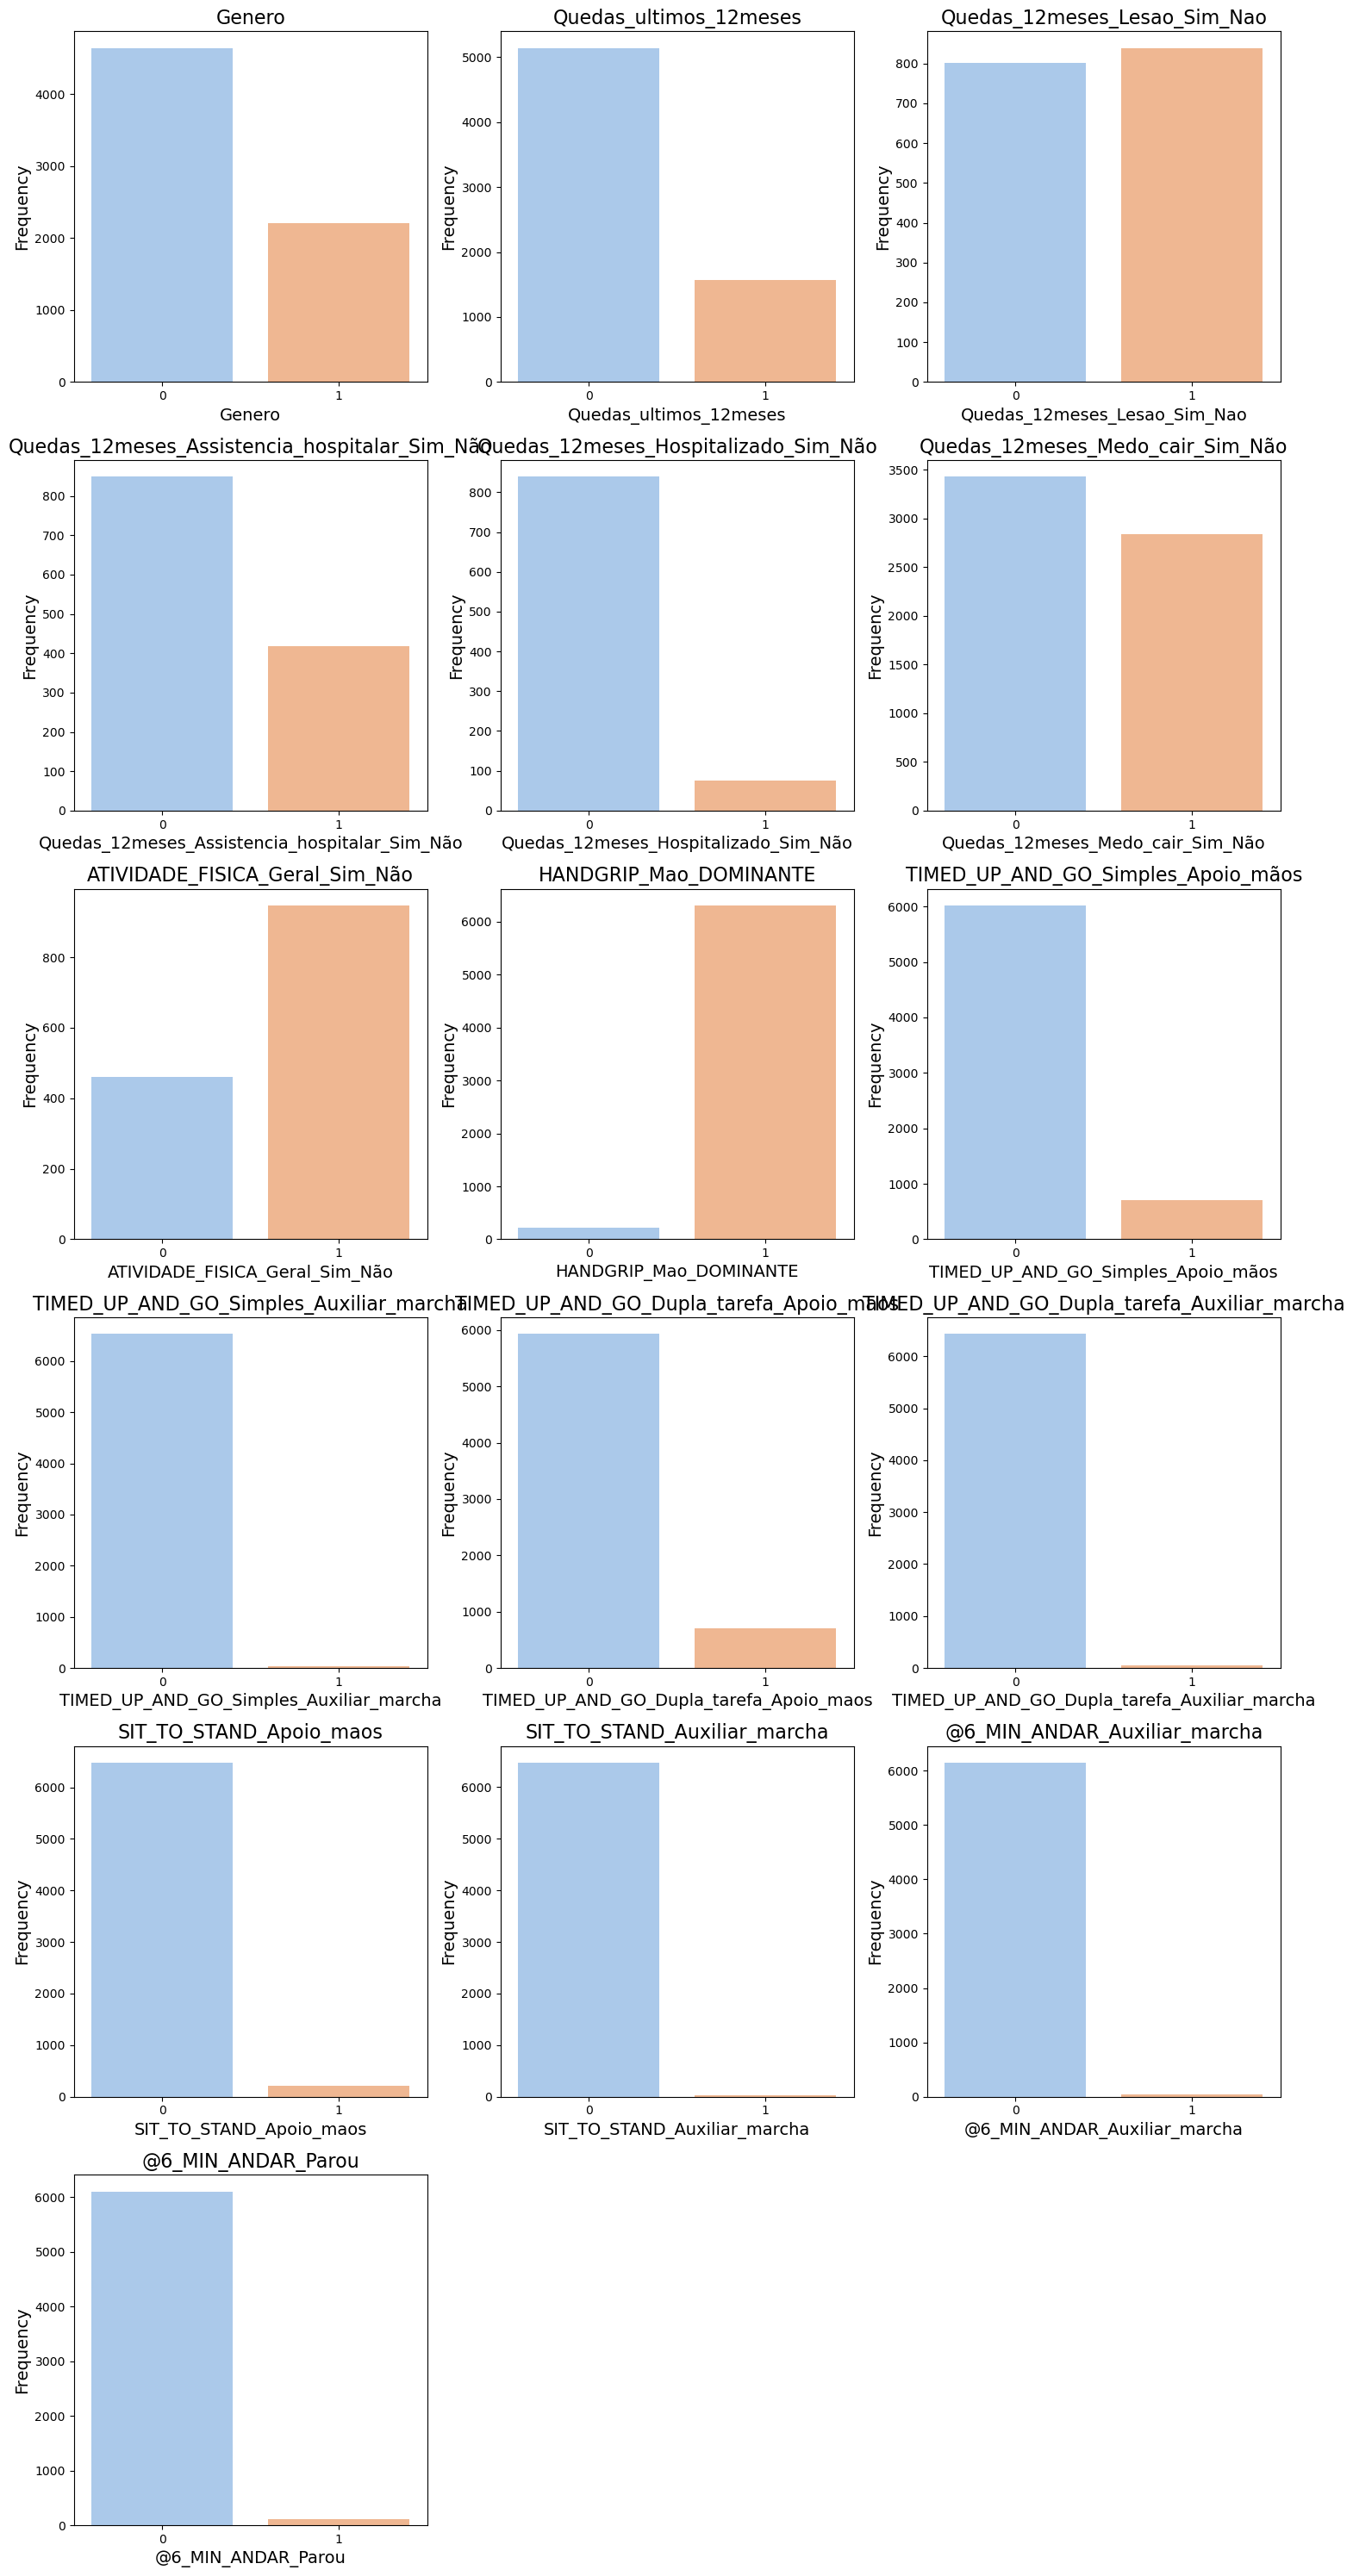

In [5]:
ncols = 3

nrows = -(-len(binary_columns) // ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i, variable in enumerate(binary_columns):
    ax = axes[i]
    sns.countplot(data = data, x = variable, ax=ax, hue = variable, palette="pastel")
    ax.legend_.remove()
    ax.set_title(variable, fontsize=16) 
    ax.set_xlabel(variable, fontsize=14) 
    ax.set_ylabel('Frequency', fontsize=14)

# Remove empty subplots
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Ordinal Columns

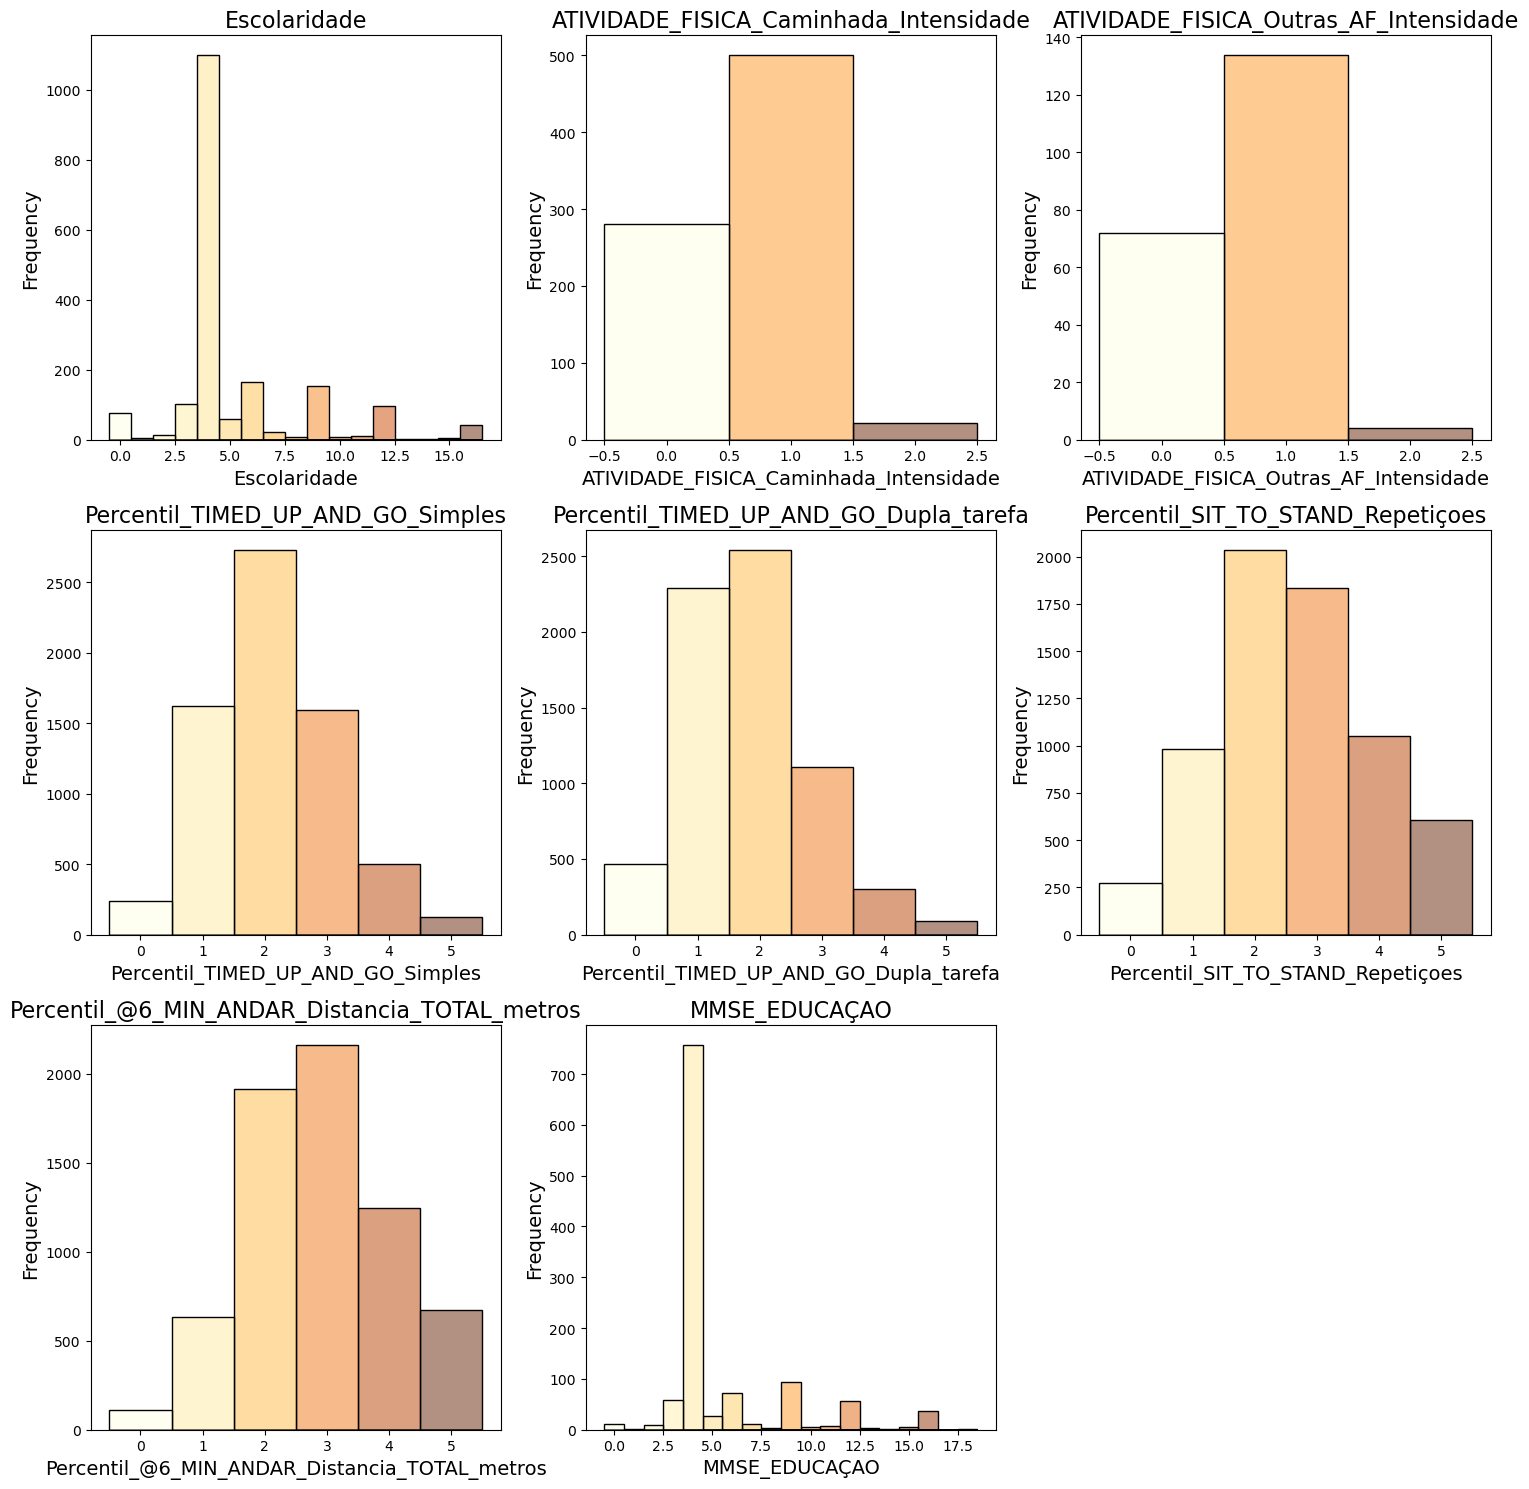

In [6]:
ncols = 3

nrows = -(-len(ordinal_columns) // ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i, variable in enumerate(ordinal_columns):
    ax = axes[i]
    sns.histplot(data = data, x = variable, ax=ax, discrete=True, hue = variable, palette="YlOrBr")
    ax.set_title(variable, fontsize=16) 
    ax.set_xlabel(variable, fontsize=14) 
    ax.set_ylabel('Frequency', fontsize=14)
    ax.legend_.remove()

# Remove empty subplots
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Nominal Columns

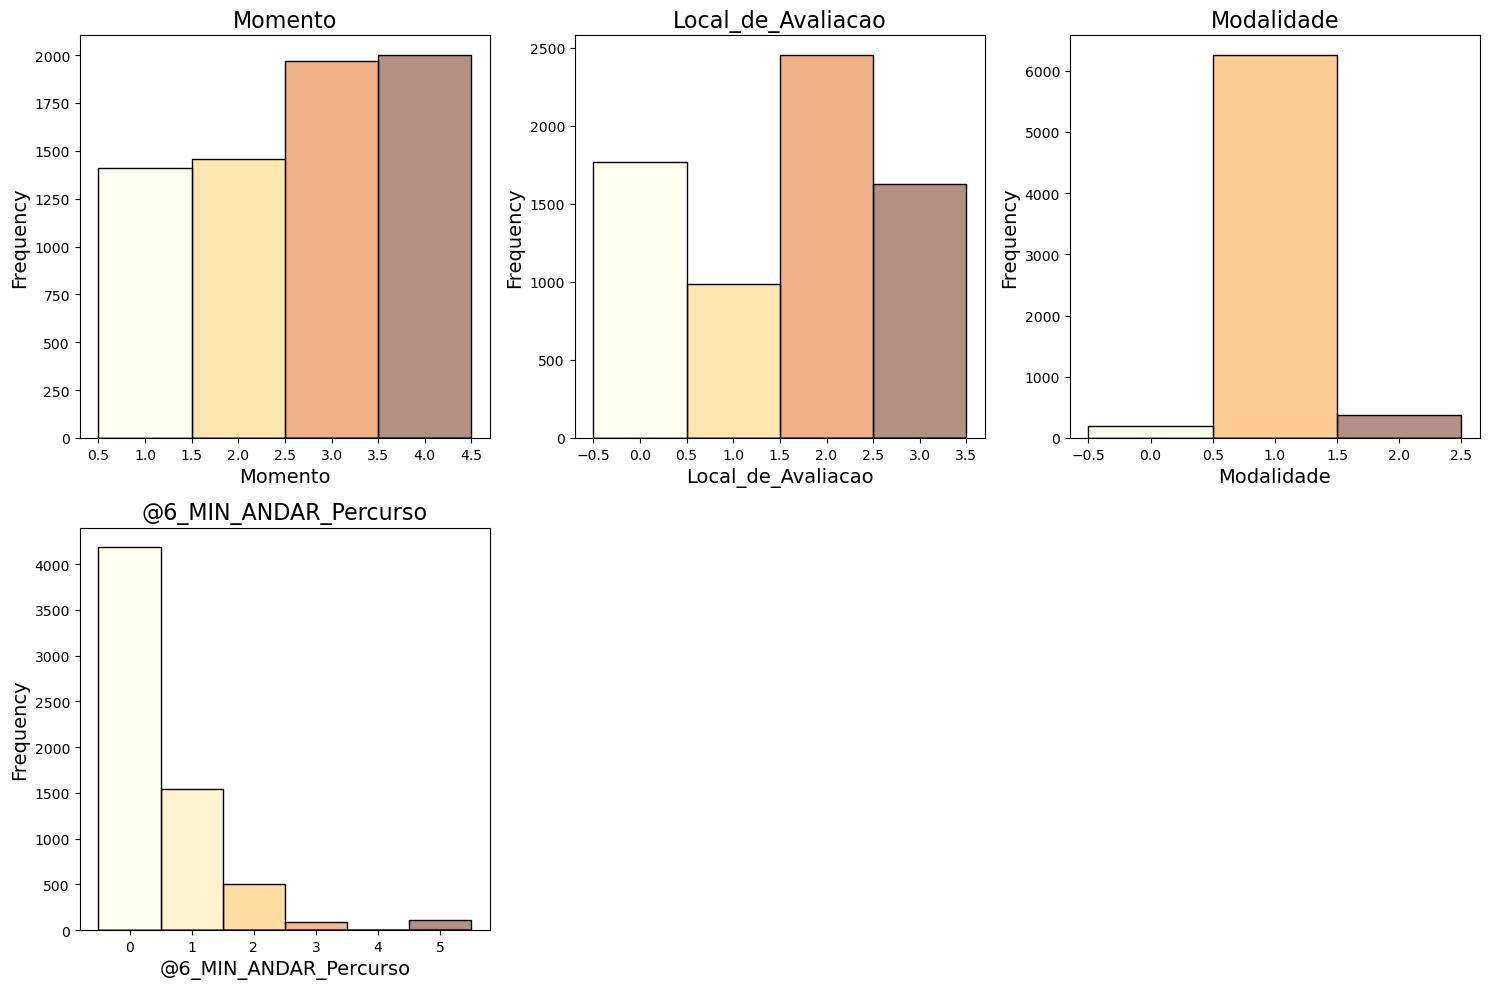

In [7]:
ncols = 3

nrows = -(-len(nominal_columns) // ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i, variable in enumerate(nominal_columns):
    ax = axes[i]
    sns.histplot(data = data, x = variable, ax=ax, discrete=True, hue = variable, palette="YlOrBr")
    ax.set_title(variable, fontsize=16) 
    ax.set_xlabel(variable, fontsize=14) 
    ax.set_ylabel('Frequency', fontsize=14)
    ax.legend_.remove()

# Remove empty subplots
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Numerical Variables

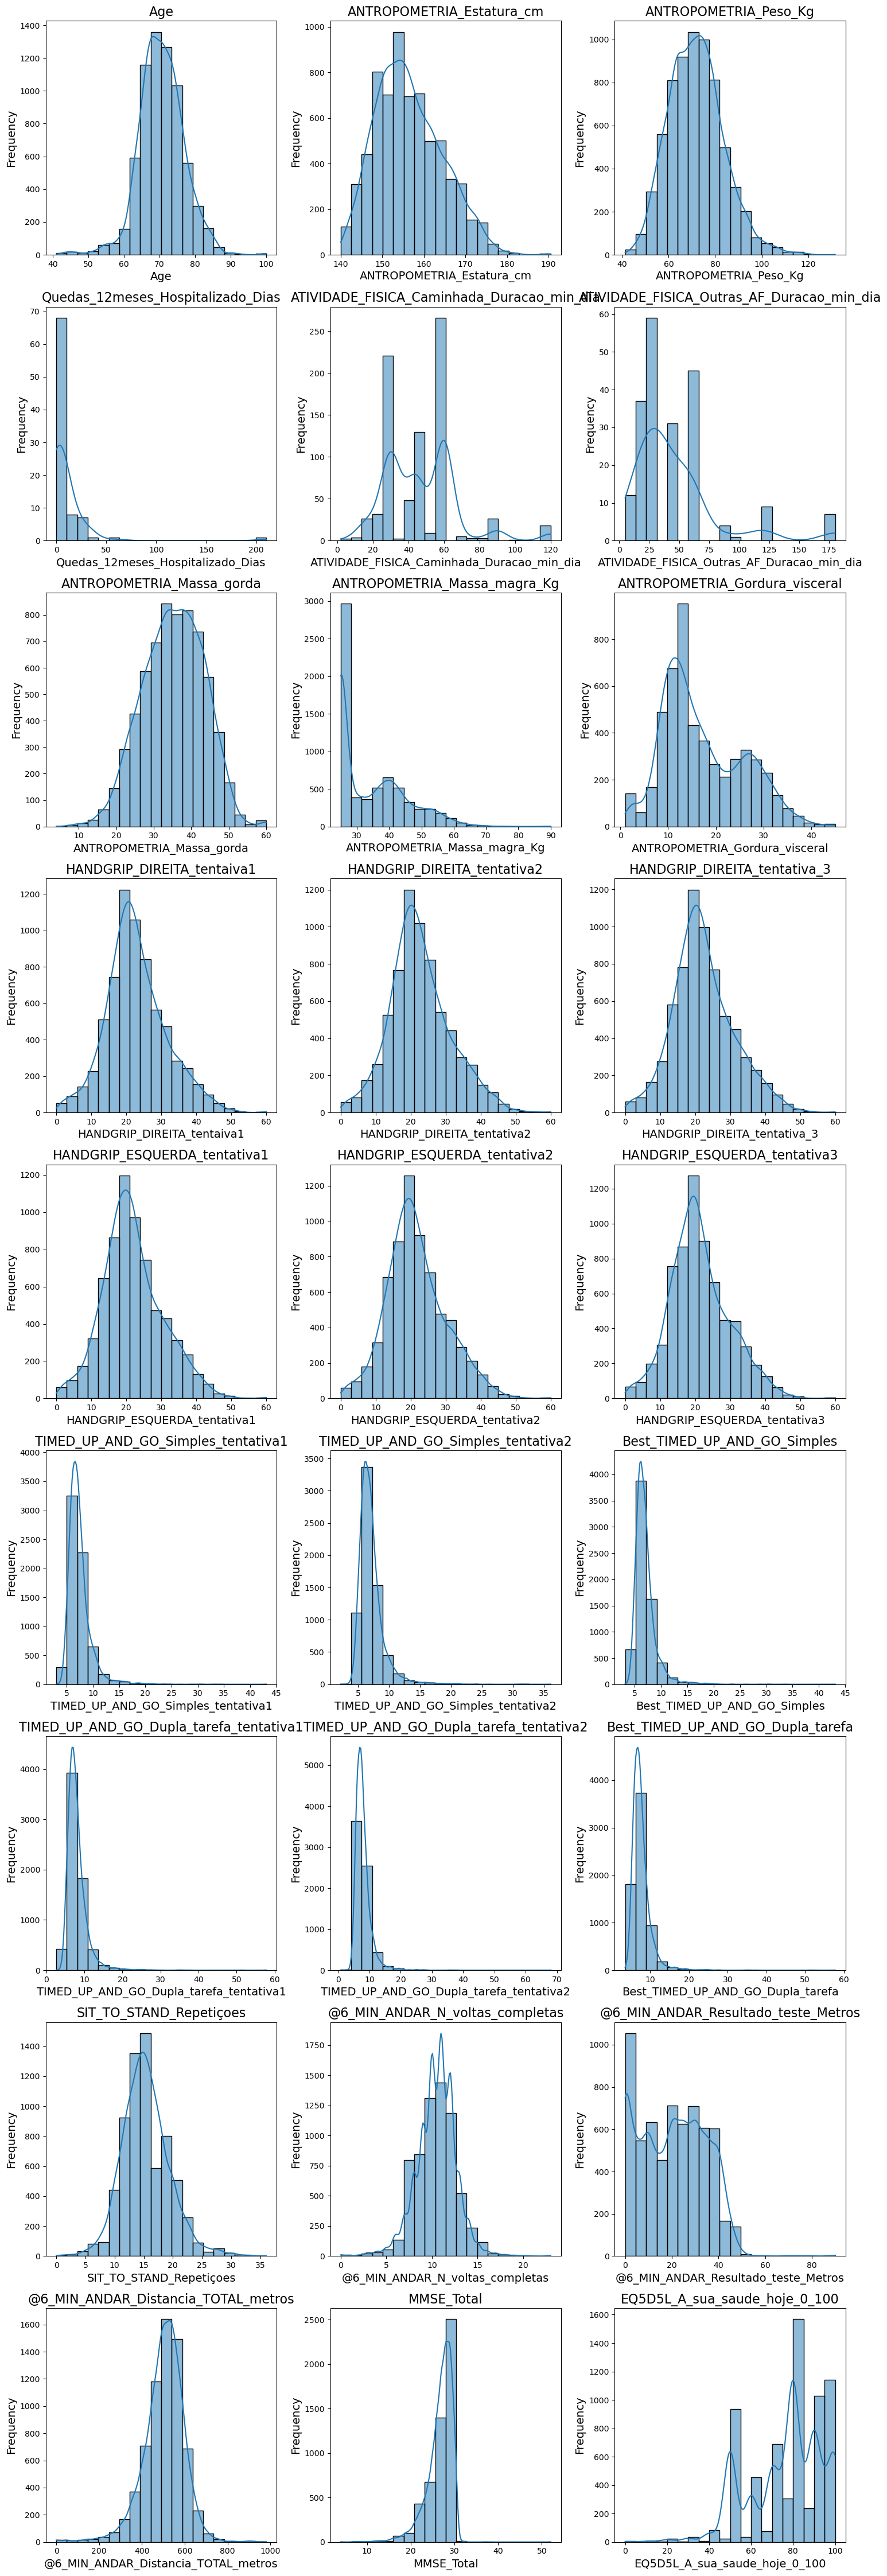

In [8]:

ncols = 3

nrows = -(-len(numerical_columns) // ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i, variable in enumerate(numerical_columns):
    ax = axes[i]
    #bins = min([len(data[variable].value_counts()),15])
    sns.histplot(data = data, x = variable, ax=ax, bins = 20, kde=True)
    ax.set_title(variable, fontsize=16) 
    ax.set_xlabel(variable, fontsize=14) 
    ax.set_ylabel('Frequency', fontsize=14)

# Remove empty subplots
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

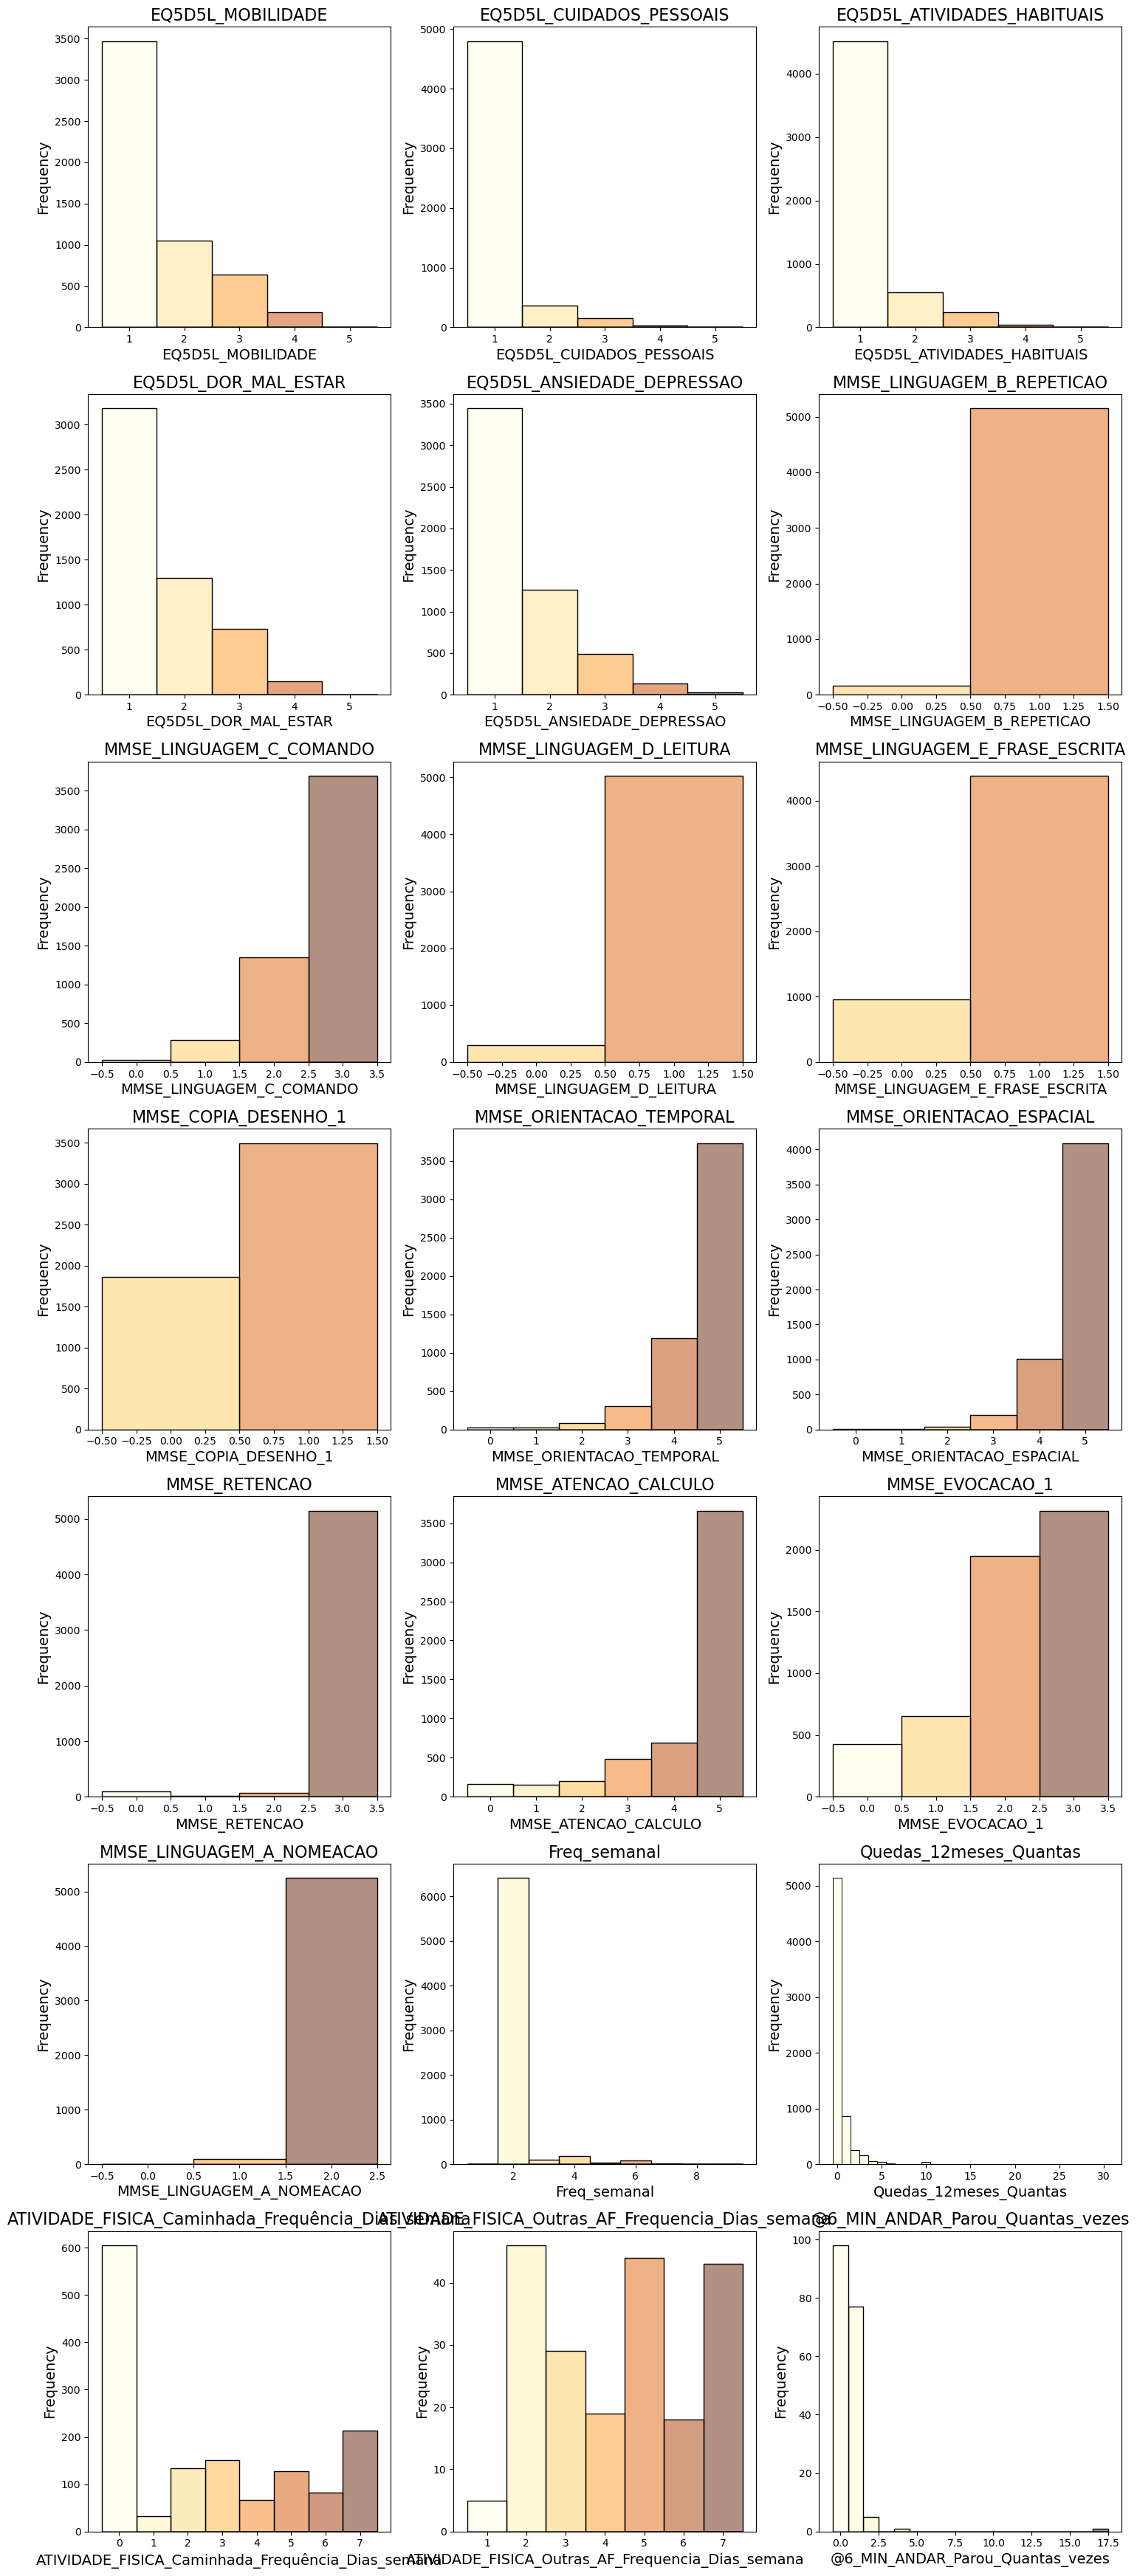

In [9]:
ncols = 3

nrows = -(-len(discrete_columns) // ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i, variable in enumerate(discrete_columns):
    ax = axes[i]
    sns.histplot(data = data, x = variable, ax=ax, discrete=True, hue = variable, palette="YlOrBr")
    ax.set_title(variable, fontsize=16) 
    ax.set_xlabel(variable, fontsize=14) 
    ax.set_ylabel('Frequency', fontsize=14)
    ax.legend_.remove()

# Remove empty subplots
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Save the data

In [10]:
data.to_csv("../data/interim/05. FRAIL_correct_dtypes.csv", index=False)